# Підключення до GBQ. Очищення даних

In [73]:
#Connect to BQ using Google Account
from google.colab import auth
import google.auth
from google.cloud import bigquery
from oauth2client.client import GoogleCredentials

auth.authenticate_user()

# Завантаження даних з BQ
project_id = 'dala-rdcc'
bigquery_client = bigquery.Client(project = project_id)
dataset_id = 'junior_da_final_project'
table_id = 'hr_analytics'

query = (
    'SELECT * '
    'FROM `%s.%s.%s` ' % (project_id, dataset_id, table_id)
    )

query_job = bigquery_client.query(query)

import pandas as pd
pd.set_option('display.max_columns', None)

df = query_job.result().to_dataframe()

df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,SalarySlab,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM1222,45,36-45,False,Non-Travel,1238,Research & Development,1,1,Life Sciences,1,1712,3,Male,74,2,3,Healthcare Representative,3,Married,10748,10k-15k,3395,3,True,False,23,4,4,80,1,25,3,2,23,15,14,4
1,RM1139,50,46-55,False,Travel_Frequently,1234,Research & Development,20,5,Medical,1,1606,2,Male,41,3,4,Healthcare Representative,3,Married,11245,10k-15k,20689,2,True,True,15,3,3,80,1,32,3,3,30,8,12,13
2,RM915,55,46-55,False,Non-Travel,177,Research & Development,8,1,Medical,1,1278,4,Male,37,2,4,Healthcare Representative,2,Divorced,13577,10k-15k,25592,1,True,True,15,3,4,80,1,34,3,3,33,9,15,0
3,RM127,58,55+,True,Travel_Rarely,147,Research & Development,23,4,Medical,1,165,4,Female,94,3,3,Healthcare Representative,4,Married,10312,10k-15k,3465,1,True,False,12,3,4,80,1,40,3,2,40,10,15,6
4,RM312,45,36-45,False,Travel_Frequently,1249,Research & Development,7,3,Life Sciences,1,425,1,Male,97,3,3,Laboratory Technician,1,Divorced,5210,5k-10k,20308,1,True,False,18,3,1,80,1,24,2,3,24,9,9,11


In [74]:
# Прибираємо непотрібні колонки

df.drop(
    [
        "DailyRate",
        "HourlyRate",
        "MonthlyRate",
        "StandardHours",
        "EmployeeCount",
        "EmployeeNumber",
        "Over18"
    ],
    axis=1,
    inplace=True,
)

df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,SalarySlab,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM1222,45,36-45,False,Non-Travel,Research & Development,1,1,Life Sciences,3,Male,2,3,Healthcare Representative,3,Married,10748,10k-15k,3,False,23,4,4,1,25,3,2,23,15,14,4
1,RM1139,50,46-55,False,Travel_Frequently,Research & Development,20,5,Medical,2,Male,3,4,Healthcare Representative,3,Married,11245,10k-15k,2,True,15,3,3,1,32,3,3,30,8,12,13
2,RM915,55,46-55,False,Non-Travel,Research & Development,8,1,Medical,4,Male,2,4,Healthcare Representative,2,Divorced,13577,10k-15k,1,True,15,3,4,1,34,3,3,33,9,15,0
3,RM127,58,55+,True,Travel_Rarely,Research & Development,23,4,Medical,4,Female,3,3,Healthcare Representative,4,Married,10312,10k-15k,1,False,12,3,4,1,40,3,2,40,10,15,6
4,RM312,45,36-45,False,Travel_Frequently,Research & Development,7,3,Life Sciences,1,Male,3,3,Laboratory Technician,1,Divorced,5210,5k-10k,1,False,18,3,1,1,24,2,3,24,9,9,11


In [75]:
# Рахуємо кількість дублікатів у записах
df.duplicated().sum()

np.int64(7)

In [76]:
# Прибираємо дублікати
df_cleaned = df.drop_duplicates().copy()

In [77]:
# Перевіряємо, чи є працівники, які зустрічаються у таблиці декілька разів
duplicate_emp = df_cleaned[df_cleaned.duplicated('EmpID')].copy()

# Виводимо працівників, які зустрічаються декілька разів в основній таблиці
df_cleaned[df_cleaned['EmpID'].isin(duplicate_emp['EmpID'])]

# Як видно з таблиці, у 3-х працівників є по два записи з єдиною відмінністю у колонці YearsWithCurrManager.
# Зверніть увагу на невідповіднсть у записі 614: працівник має 4 роки у компанії і 5 років під поточним менеджером. Виходить, що дублюючі записи створюють аномалії

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,SalarySlab,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
613,RM1465,26,26-35,False,Travel_Rarely,Sales,5,3,Other,4,Female,2,1,Sales Representative,3,Single,2966,Upto 5k,0,False,18,3,4,0,5,2,3,4,2,0,0
614,RM1465,26,26-35,False,Travel_Rarely,Sales,5,3,Other,4,Female,2,1,Sales Representative,3,Single,2966,Upto 5k,0,False,18,3,4,0,5,2,3,4,2,0,5
665,RM1466,36,36-45,False,Travel_Frequently,Research & Development,23,2,Medical,3,Male,4,2,Laboratory Technician,4,Married,2571,Upto 5k,4,False,17,3,3,1,17,3,3,5,2,0,3
666,RM1466,36,36-45,False,Travel_Frequently,Research & Development,23,2,Medical,3,Male,4,2,Laboratory Technician,4,Married,2571,Upto 5k,4,False,17,3,3,1,17,3,3,5,2,0,2
901,RM1467,39,36-45,False,Travel_Rarely,Research & Development,6,1,Medical,4,Male,2,3,Healthcare Representative,1,Married,9991,5k-10k,4,False,15,3,1,1,9,5,3,7,7,1,7
902,RM1467,39,36-45,False,Travel_Rarely,Research & Development,6,1,Medical,4,Male,2,3,Healthcare Representative,1,Married,9991,5k-10k,4,False,15,3,1,1,9,5,3,7,7,1,1


In [78]:
# Видаляю дублікати, оскільки вони створюють аномалії ()
df_cleaned.drop([614, 666, 902], axis = 0, inplace = True)

In [79]:
# Дивимося, в яких колонках є NA значення
df_cleaned.isnull().sum()

# NA є у колонці YearsWithCurrManager. Залишаємо колонку, оскільки вона не заважає аналізу

,0
EmpID,0
Age,0
AgeGroup,0
Attrition,0
BusinessTravel,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0


In [80]:
# Перевіряємо типи даних
df_cleaned.dtypes

,0
EmpID,object
Age,Int64
AgeGroup,object
Attrition,boolean
BusinessTravel,object
Department,object
DistanceFromHome,Int64
Education,Int64
EducationField,object
EnvironmentSatisfaction,Int64


# Пошук аномальних значень

In [81]:
# Перевіряємо мінімальні і максимальні значення у колонках, щоб знайти аномалії
df_cleaned.describe()
# Аномально високих або низьких значень не виявлено

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1413.0
mean,36.92381,9.192517,2.912925,2.721769,2.729932,2.063946,2.728571,6502.931293,2.693197,15.209524,3.153741,2.712245,0.793878,11.279592,2.79932,2.761224,7.008163,4.229252,2.187755,4.120311
std,9.135373,8.106864,1.024165,1.093082,0.711561,1.10694,1.102846,4707.956783,2.498009,3.659938,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.22243,3.561633
min,18.0,1.0,1.0,1.0,1.0,1.0,1.0,1009.0,0.0,11.0,3.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
25%,30.0,2.0,2.0,2.0,2.0,1.0,2.0,2911.0,1.0,12.0,3.0,2.0,0.0,6.0,2.0,2.0,3.0,2.0,0.0,2.0
50%,36.0,7.0,3.0,3.0,3.0,2.0,3.0,4919.0,2.0,14.0,3.0,3.0,1.0,10.0,3.0,3.0,5.0,3.0,1.0,3.0
75%,43.0,14.0,4.0,4.0,3.0,3.0,4.0,8379.0,4.0,18.0,3.0,4.0,1.0,15.0,3.0,3.0,9.0,7.0,3.0,7.0
max,60.0,29.0,5.0,4.0,4.0,5.0,4.0,19999.0,9.0,25.0,4.0,4.0,3.0,40.0,6.0,4.0,40.0,18.0,15.0,17.0


In [82]:
# За допомогою функції unique() перевірила значення в усіх колонках типу object, наприклад:
print(df_cleaned['BusinessTravel'].unique())
# Виявлена аномалія у колонці BusinessTravel: значення Travel_Rarely і TravelRarely

['Non-Travel' 'Travel_Frequently' 'Travel_Rarely' 'TravelRarely']


In [83]:
# Змінюємо значення TravelRarely на Travel_Rarely
df_cleaned.loc[df_cleaned['BusinessTravel'] == 'TravelRarely', 'BusinessTravel'] = 'Travel_Rarely'

In [84]:
# Знову перевіряємо коректність значень
print(df_cleaned['BusinessTravel'].unique())

['Non-Travel' 'Travel_Frequently' 'Travel_Rarely']


In [85]:
# Перевіряємо аномалії в колонках TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager

df_cleaned[
    (df_cleaned.TotalWorkingYears < df_cleaned.YearsAtCompany) |
    (df_cleaned.YearsAtCompany < df_cleaned.YearsInCurrentRole) |
    (df_cleaned.YearsAtCompany < df_cleaned.YearsWithCurrManager)
]

# Аномалій не виявлено

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,SalarySlab,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


# Первинний аналіз відтоку працівників

## Яким є загальний коефіцієнт відтоку у компанії?

Коефіцієнт відтоку відображає відсоток звільнень за певний період. Він розраховується діленням кількості співробітників, які покинули компанію протягом певного періоду, на середню кількість співробітників за той же період.

Оскільки датасет не містить інформації про час звільнення/заповення вакансій, ми рахуватимемо коефіцієнт як кількість звільнених працівників поділена на загальну кількість працівників.

In [86]:
attrition_rate = round(df_cleaned["Attrition"].mean() * 100)

print(f"Коефіцієнт відтоку: {attrition_rate}%")

Коефіцієнт відтоку: 16%


Здоровим коефіцієнтом відтоку, загальноприйнято, вважається значення у проміжку 5-10%. **Значення у 16% сильно перевищує норму**, що спонукає до подальшого аналізу причин.

## Які відділи втрачають найбільше працівників?

In [87]:
# Групуємо дані за відділами і рахуємо, який відсоток від усіх працівників відділу звільнено
attr_department = round(
    df_cleaned.groupby("Department")["Attrition"].mean() * 100, 1
).reset_index()


attr_department = attr_department.sort_values(
    by="Attrition", ascending=False
).reset_index(drop=True)

attr_department['Attrition'] = attr_department['Attrition'].astype(str) + '%'

attr_department

,Department,Attrition
0,Sales,20.6%
1,Human Resources,19.0%
2,Research & Development,13.8%


У відділах **Sales** та **Human Resources** найвищий коефіцієнт відтоку.

## Які посади втрачають найбільше працівників?

In [88]:
# Групуємо дані за посадами і рахуємо, яка посада має найвищий коефіцієнт відтоку
attr_jobrole = round(
    df_cleaned.groupby("JobRole")["Attrition"].mean() * 100, 1
).reset_index()


attr_jobrole = attr_jobrole.sort_values(by='Attrition', ascending=True).reset_index(drop=True)

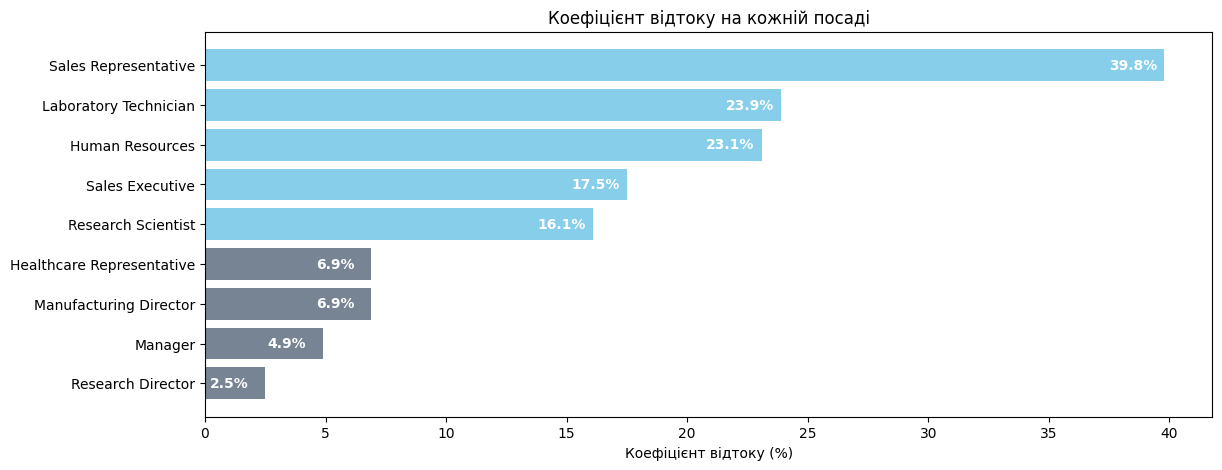

In [89]:
# Малюємо горизонтальну стовпчикову діаграму
import matplotlib.pyplot as plt

cutoff = 10
highlight_color = '#87CEEB'
base_color = '#768493'

attr_jobrole['color'] = attr_jobrole['Attrition'].apply(lambda x: highlight_color if x > cutoff else base_color)

fig, ax = plt.subplots(figsize=(13,5))

bars = plt.barh(attr_jobrole['JobRole'], attr_jobrole['Attrition'], color=attr_jobrole['color'])

ax.set_xlabel('Коефіцієнт відтоку (%)')

ax.bar_label(bars, padding=-40, color='white', fontsize=10, label_type='edge', fmt='%.1f%%', fontweight='bold')

ax.set_title('Коефіцієнт відтоку на кожній посаді')

plt.show()

До відділу **Sales** належить 2 посади. Лідером відтоку стала посада **"Sales Representative" (40%)**. Посада **"Sales Executive"** посіла 4-те місце із коефіцієнтом **17.5%**

Відділ **Research & Development** налічує 5 посад. Серед них **Laboratory Technician** посіла друге місце (**24%**), а посада **Research Scientist** посіла 5-те місце (**16%**).

Єдина посада відділу **Human Resources** посіла 3-тє місце із коефіцієнтом **23%**.


## На яких рівнях посад коефіцієнт відтоку найвищий?

In [90]:
# Забираємо інформацію про посади з найвищим рівнем відтоку
boolean_mask = df_cleaned['JobRole'].isin(attr_jobrole.loc[4:, 'JobRole'])
high_attr_roles = df_cleaned[boolean_mask].copy()

In [91]:
# Групуємо дані за відділом, посадою і рівнем посади; рахуємо, який відсоток від усіх працівників на поточному місці звільнені
attr_dep_level = round(
    high_attr_roles.groupby(["Department", "JobRole", "JobLevel"])["Attrition"].mean()
    * 100, 1
).reset_index()

attr_dep_level = attr_dep_level.sort_values(
    by=["Department", "JobRole", "JobLevel"], ascending=[True, True, True]
).reset_index(drop=True)

In [92]:
attr_dep_level.pivot_table(
    index=['Department', 'JobRole'],
    columns='JobLevel',
    values='Attrition'
).style.format("{:.1f}%", na_rep="")

Серед **Human Resources**, найчастіше звільняються працівники **1** і **3** рівня (~30%).

Серед Research & Development лідерами відтоку є: **Laboratory Technician** — позиції **1** і **3** рівня (~30%); **Research Scientist** — позиції **1** рівня (19%).

У Sales відділі позиції Sales Executive і Sales Representative позиції мають протилежні динаміки. Для **Sales Executive** коефіцієнт відторку **росте із підвищенням рівня посади**; для **Sales Representative** найвищий коефіцієнт відтоку на посаді **1** рівня (42%), а на посаді 2 рівня коефіцієнт набаго нижчий (14%).

## Який середній термін роботи на кожній посаді?

In [93]:
# Групуємо дані за посадами і рахуємо середній термін роботи і медіанне значення
jobrole_avg_y = df_cleaned.groupby('JobRole')['YearsAtCompany'].agg(['mean', 'median']).reset_index()
jobrole_avg_y['mean'] = round(jobrole_avg_y['mean']).astype("int64")
jobrole_avg_y['median'] = round(jobrole_avg_y['median']).astype("int64")
jobrole_avg_y = jobrole_avg_y.sort_values(by='mean', ascending=True).reset_index(drop=True)

In [94]:
jobrole_avg_y

,JobRole,mean,median
0,Sales Representative,3,2
1,Human Resources,5,5
2,Research Scientist,5,4
3,Laboratory Technician,5,4
4,Sales Executive,7,7
5,Manufacturing Director,8,7
6,Healthcare Representative,8,7
7,Research Director,11,9
8,Manager,14,12


Найменше затримуються **Sales Representative** працівники — найчастіше їхній термін роботи складає **2 роки**.

Працівники на посадах **Human Resources**, **Research Scientist** та **Laboratory Technician** працюють суттєво довше — **4-5 років**.

Працівники на інших посадах затримуються на 7 років і довше.

# Аналіз рівня задоволеності місцем роботи

## Яким є середній рівень задоволеності місцем роботи?

In [95]:
# Створюємо нову колонку, в яку запишемо середнє значення з колонок EnvironmentSatisfaction, JobSatisfaction, RelationshipSatisfaction, WorkLifeBalance
employees = df_cleaned.copy()
employees["AvgSatisfaction"] = round(
    (
        employees["EnvironmentSatisfaction"]
        + employees["JobSatisfaction"]
        + employees["RelationshipSatisfaction"]
        + employees["WorkLifeBalance"]
    )
    / 4,
    1,
)

employees.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,SalarySlab,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AvgSatisfaction
0,RM1222,45,36-45,False,Non-Travel,Research & Development,1,1,Life Sciences,3,Male,2,3,Healthcare Representative,3,Married,10748,10k-15k,3,False,23,4,4,1,25,3,2,23,15,14,4,3.0
1,RM1139,50,46-55,False,Travel_Frequently,Research & Development,20,5,Medical,2,Male,3,4,Healthcare Representative,3,Married,11245,10k-15k,2,True,15,3,3,1,32,3,3,30,8,12,13,2.8
2,RM915,55,46-55,False,Non-Travel,Research & Development,8,1,Medical,4,Male,2,4,Healthcare Representative,2,Divorced,13577,10k-15k,1,True,15,3,4,1,34,3,3,33,9,15,0,3.2
3,RM127,58,55+,True,Travel_Rarely,Research & Development,23,4,Medical,4,Female,3,3,Healthcare Representative,4,Married,10312,10k-15k,1,False,12,3,4,1,40,3,2,40,10,15,6,3.5
4,RM312,45,36-45,False,Travel_Frequently,Research & Development,7,3,Life Sciences,1,Male,3,3,Laboratory Technician,1,Divorced,5210,5k-10k,1,False,18,3,1,1,24,2,3,24,9,9,11,1.5


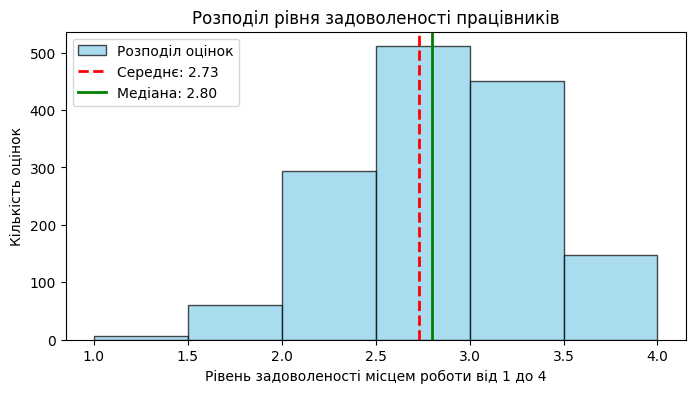

In [96]:
import numpy as np

mean_sat = np.mean(employees['AvgSatisfaction'])
median_sat = np.median(employees['AvgSatisfaction'])

plt.figure(figsize=(8, 4))
plt.hist(employees['AvgSatisfaction'], bins=6, color='skyblue', edgecolor='black', alpha=0.7, label='Розподіл оцінок')

# Mean line
plt.axvline(mean_sat, color='red', linestyle='dashed', linewidth=2, label=f'Середнє: {mean_sat:.2f}')
# Median line
plt.axvline(median_sat, color='green', linestyle='solid', linewidth=2, label=f'Медіана: {median_sat:.2f}')

plt.xlabel('Рівень задоволеності місцем роботи від 1 до 4')
plt.ylabel('Кількість оцінок')
plt.title('Розподіл рівня задоволеності працівників')
plt.legend()

plt.show()

Середнє значення задоволеності роботою в компанії — 2,73, де максимальний бал 4, а мінімальний бал 1. Медіанне значення — 2.8. **Більшість працівників оцінюють роботу в компанії на рівні від 2,5 до 3 балів**.

## Чи спонукає низький рівень задоволеності до звільнення?

In [97]:
# Створюємо групи на основі рівня задоволеності
def group_by_sat(satisfaction):
    if satisfaction <= 2:
        return 'Low'
    elif satisfaction <= 3:
        return 'Medium'
    else:
        return 'High'

employees['SatGroup'] = employees['AvgSatisfaction'].apply(group_by_sat)

In [98]:
# Групуємо працівників і рахуємо коефіцієнт відтоку у кожній групі
attr_sat = round(
    employees.groupby("SatGroup")["Attrition"].mean()
    * 100, 1
).reset_index()

attr_sat = attr_sat.sort_values(by='Attrition', ascending=False).reset_index(drop=True)

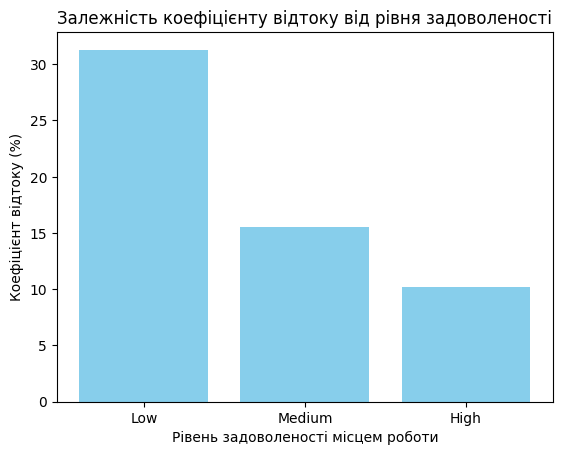

In [99]:
plt.bar(attr_sat['SatGroup'], attr_sat['Attrition'], color='skyblue')

plt.xlabel('Рівень задоволеності місцем роботи')
plt.ylabel('Коефіцієнт відтоку (%)')

plt.title('Залежність коефіцієнту відтоку від рівня задоволеності')

plt.show()

Як висновок, **рівень задоволеності місцем роботи має негативну кореляцію із коефіцієнтом відтоку**.

## Який рівень задоволеності у працівників різних відділів?

In [100]:
# Групуємо дані за відділом і рахуємо середній рівень задоволеності у кожній категорії
sat_by_depts = employees.groupby('Department').agg(
    Environment=('EnvironmentSatisfaction', 'mean'),
    Job=('JobSatisfaction', 'mean'),
    Relationship=('RelationshipSatisfaction', 'mean'),
    WorkLifeBalance=('WorkLifeBalance', 'mean')
)

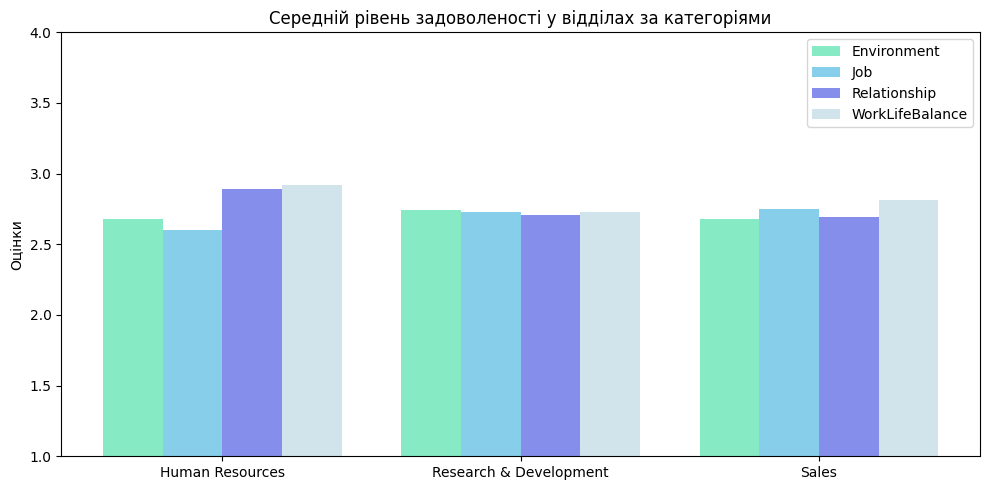

In [101]:
groups = sat_by_depts.index.copy()
x = np.arange(len(groups))
y1 = sat_by_depts['Environment'].copy()
y2 = sat_by_depts['Job'].copy()
y3 = sat_by_depts['Relationship'].copy()
y4 = sat_by_depts['WorkLifeBalance'].copy()
width = 0.2

fig1, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(x - (width * 1.5), y1, width, label='Environment', color='#86EBC5')
ax1.bar(x - (width * 0.5), y2, width, label='Job', color='#87CEEB')
ax1.bar(x + (width * 0.5), y3, width, label='Relationship', color='#868EEB')
ax1.bar(x + (width * 1.5), y4, width, label='WorkLifeBalance', color='#D2E4EB')

ax1.set_ylabel('Оцінки')
ax1.set_ylim(1, 4)
ax1.set_title('Середній рівень задоволеності у відділах за категоріями')
ax1.set_xticks(x)
ax1.set_xticklabels(groups)
ax1.legend()

plt.tight_layout()
plt.show()

In [102]:
# Беремо стовпчик AvgSatisfaction і рахуємо середній бал задоволеності у кожному відділі
employees.groupby('Department')['AvgSatisfaction'].mean().reset_index()

,Department,AvgSatisfaction
0,Human Resources,2.769841
1,Research & Development,2.724454
2,Sales,2.734753


Найвищий середній бал задоволеності у відділі **Human Resources (2.8)**. У них також найбільша варіативність балів за категоріями: кращі оцінки у категоріях "WorkLifeBalance" і "Relationship" та найнижчі оцінки у категоріях "Environment" та "Job".

Відділи **Research & Development** і **Sales** ідуть приблизно на одному рівні (**2.7**) з мінімальною варіативністю балів у категоріях задоволеності.

## На яких посадах найнижчий рівень задоволеності?

In [103]:
# Групуємо дані за посадами і рахуємо середній рівень задоволеності
sat_jobrole = round(employees.groupby('JobRole')['AvgSatisfaction'].mean(), 1).reset_index()
sat_jobrole = sat_jobrole.sort_values(by='AvgSatisfaction', ascending=True).reset_index(drop=True)

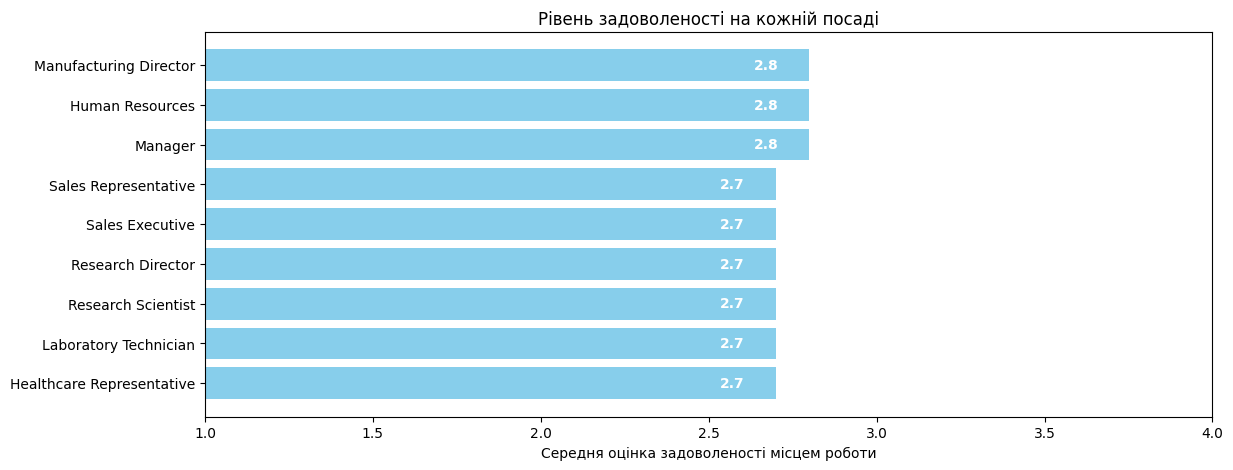

In [104]:
cutoff = 2
highlight_color = '#87CEEB'
base_color = '#768493'

sat_jobrole['color'] = sat_jobrole['AvgSatisfaction'].apply(lambda x: highlight_color if x > cutoff else base_color)

fig2, ax2 = plt.subplots(figsize=(13,5))

bars = plt.barh(sat_jobrole['JobRole'], sat_jobrole['AvgSatisfaction'], color=sat_jobrole['color'])

plt.xlim(1, 4)

ax2.set_xlabel('Середня оцінка задоволеності місцем роботи')

ax2.bar_label(bars, padding=-40, color='white', fontsize=10, label_type='edge', fontweight='bold')

ax2.set_title('Рівень задоволеності на кожній посаді')

plt.show()

Всі посади мають **приблизно однаковий рівень**.

## Чи відрізняється середній рівень задоволеності в залежності від статі?

In [105]:
# Групуємо дані за статтю і рахуємо середній рівень задоволеності
sat_gender = round(employees.groupby('Gender')['AvgSatisfaction'].mean(), 1).reset_index()
sat_gender = sat_gender.sort_values(by='AvgSatisfaction', ascending=True).reset_index(drop=True)

In [106]:
sat_gender

,Gender,AvgSatisfaction
0,Female,2.7
1,Male,2.7


**Різниці не виявлено**.

## Аналіз факторів, які впливають на рівень задоволеності місцем роботи

### Чи впливають відрядження на рівень задоволеності?

In [107]:
# Групуємо працівників за частотою відряджень і рахуємо рівень задоволеності у кожній групі
sat_travel = round(employees.groupby('BusinessTravel')['AvgSatisfaction'].mean(), 1).reset_index()
sat_travel = sat_travel.sort_values(by='AvgSatisfaction', ascending=False).reset_index(drop=True)

In [108]:
sat_travel

,BusinessTravel,AvgSatisfaction
0,Non-Travel,2.8
1,Travel_Frequently,2.8
2,Travel_Rarely,2.7


**Закономірності не виявлено.**

### Аналіз інших факторів

In [109]:
# Будуємо кореляційну матрицю для аналізу декількох факторів
for_corr = employees[['AvgSatisfaction', 'OverTime', 'Age', 'DistanceFromHome',
                      'MonthlyIncome', 'YearsSinceLastPromotion',
                      'YearsAtCompany', 'YearsWithCurrManager']]

corr = for_corr.corr()
corr

,AvgSatisfaction,OverTime,Age,DistanceFromHome,MonthlyIncome,YearsSinceLastPromotion,YearsAtCompany,YearsWithCurrManager
AvgSatisfaction,1.000000,0.066402,0.025536,-0.017721,0.017041,0.022072,0.012877,-0.017269
OverTime,0.066402,1.000000,0.028062,0.025514,0.006089,-0.012239,-0.011687,-0.039882
Age,0.025536,0.028062,1.000000,-0.001686,0.497855,0.216513,0.311309,0.211293
DistanceFromHome,-0.017721,0.025514,-0.001686,1.000000,-0.017014,0.010029,0.009508,0.013543
MonthlyIncome,0.017041,0.006089,0.497855,-0.017014,1.000000,0.344978,0.514285,0.344448
YearsSinceLastPromotion,0.022072,-0.012239,0.216513,0.010029,0.344978,1.000000,0.618409,0.513396
YearsAtCompany,0.012877,-0.011687,0.311309,0.009508,0.514285,0.618409,1.000000,0.765179
YearsWithCurrManager,-0.017269,-0.039882,0.211293,0.013543,0.344448,0.513396,0.765179,1.000000


Text(0.5, 1.0, 'Кореляційна матриця: Середній рівень задоволеності vs інші фактори')

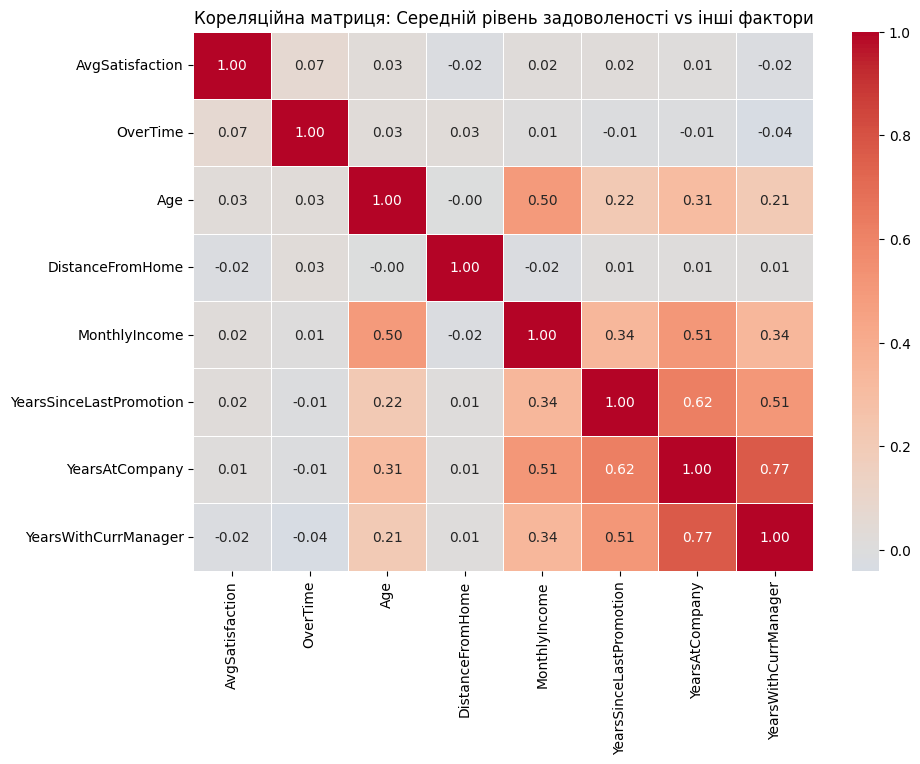

In [110]:
import seaborn as sns

fig3, ax3 = plt.subplots(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    ax=ax3
)

ax3.set_title("Кореляційна матриця: Середній рівень задоволеності vs інші фактори")

Сильної кореляції між рівнем задоволеності та наявними змінними **не виявлено**. Поточний набір даних показує, що рівень задоволеності розподілений досить рівномірно між працівниками різних груп.

---

**Висновок**:
Хоча середній рівень задоволеності працівників є відносно стабільним по всій компанії (2,7), **працівники з нижчими показниками задоволеності демонструють значно вищі показники відтоку**. Це свідчить про те, що задоволеність все ж відіграє важливу роль в утриманні працівників.

# Сегментований аналіз відтоку

## Sales Representative — плинність молодого персоналу

In [111]:
# Створюємо датафрейм, який містить інформацію про робітників позиції Sales Representative
sales_repr = employees[employees['JobRole'] == 'Sales Representative'].copy()
sales_repr['Статус працівника'] = sales_repr['Attrition'].apply(lambda x: "Звільнився" if x else "Працює")

### Аналіз віку і доходу працівників різних статусів

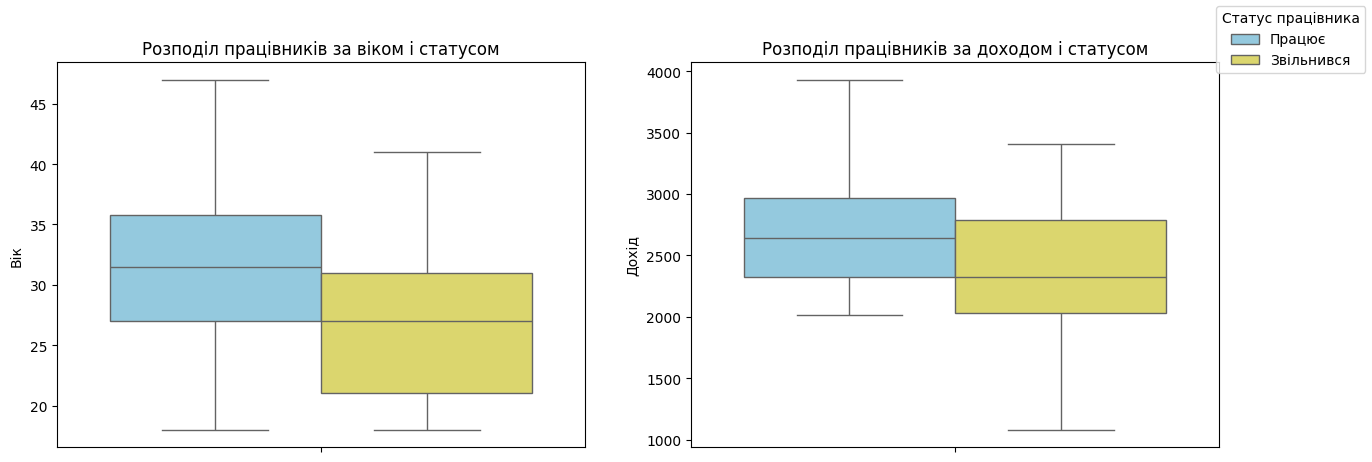

In [112]:
fig4, ax4 = plt.subplots(1, 2, figsize=(15, 5))
axes = ax4.flatten()

custom_colors = ["#87CEEB", "#EDE65C"]

sns.boxplot(ax=ax4[0], data=sales_repr, y="Age", hue="Статус працівника", palette=custom_colors, showfliers=False)
ax4[0].set_title('Розподіл працівників за віком і статусом')
ax4[0].set_ylabel('Вік')
ax4[0].get_legend().remove()

sns.boxplot(ax=ax4[1], data=sales_repr, y="MonthlyIncome", hue="Статус працівника", palette=custom_colors, showfliers=False)
ax4[1].set_title('Розподіл працівників за доходом і статусом')
ax4[1].set_ylabel('Дохід')
ax4[1].get_legend().remove()

handles, labels = ax4[0].get_legend_handles_labels()
fig4.legend(handles, labels, title="Статус працівника", loc="upper right")
plt.show()

На коробкових графіках видно, що **75% звільнених працівників на посаді Sales Representative молодші 30 років**, тоді як діючі працівники в середньому старші на 5 років — діапазон від першого квартиля до третього квартиля охоплює 27-35 років.

**Медіанне значення зарплат звільнених працівників на 500 одиниць валюти менше** за медіану дійсних працівників. Найменші зарплати у датасеті також відносяться до звільнених працівників.



### Розподіл звільнених працівників за терміном перебування на посаді

In [113]:
# Відносимо кожного працівника у групу в залежності від терміну перебування на посаді
def tenure(years):
    if years <= 1:
        return '0-1'
    elif years <= 3:
        return '2-3'
    elif years <= 5:
        return '4-5'
    else:
        return '6+'

sales_repr['Tenure'] = sales_repr['YearsInCurrentRole'].apply(tenure)

In [114]:
# Забираємо звільнених працівників
attr_sr = sales_repr[sales_repr['Attrition'] == True].copy()

# Групуємо працівників і рахуємо кількість у кожній групі
attr_sr_tenure = attr_sr.groupby('Tenure', as_index=False).size()

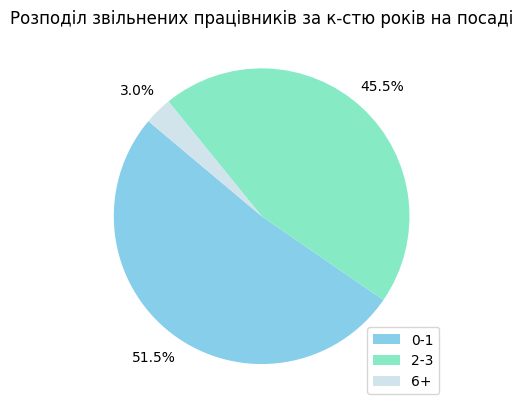

In [115]:
pie_colors = ['#87CEEB', '#86EBC5', '#D2E4EB']

plt.pie(
    attr_sr_tenure["size"],
    labels=attr_sr_tenure["Tenure"],
    colors=pie_colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=1.2,
    labeldistance=None,
)

plt.legend()

plt.title('Розподіл звільнених працівників за к-стю років на посаді')

plt.show()

Серед усіх звільнених працівників на посаді Sales Representative **51% залишили компанію у перший рік роботи**. **97% залишили компанію у перші 3 роки** роботи на посаді.

### Аналіз вливу двох факторів: вік + схильність до понаднормової праці

In [116]:
# Групуємо працівників за віковою групою та наявністю овертаймів; рахуємо коефіцієнт відтоку в кожній групі
sr_age_ot = round(
    sales_repr.groupby(["AgeGroup", "OverTime"])["Attrition"].mean() * 100,
    1,
).unstack()

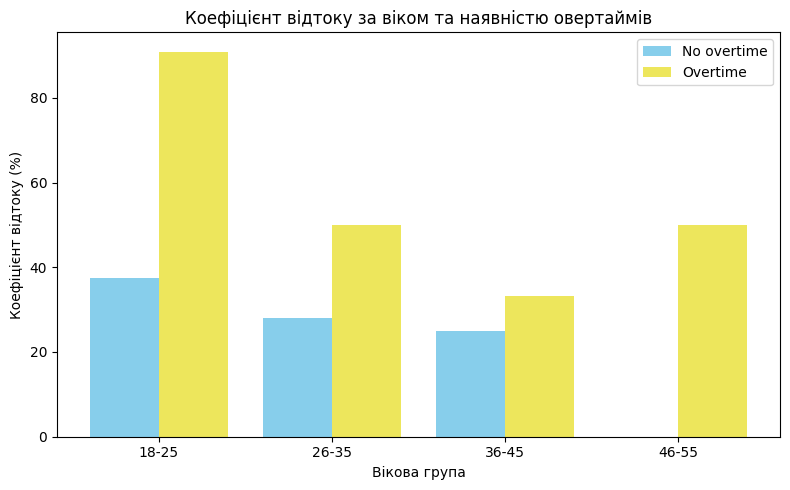

In [117]:
sr_age_groups = sr_age_ot.index.copy()
x = np.arange(len(sr_age_groups))
y_false = sr_age_ot[False].copy()
y_true = sr_age_ot[True].copy()
width = 0.4

fig5, ax5 = plt.subplots(figsize=(8, 5))

ax5.bar(x - width/2, y_false, width, label='No overtime', color='#87CEEB')
ax5.bar(x + width/2, y_true, width, label='Overtime', color='#EDE65C')

ax5.set_ylabel('Коефіцієнт відтоку (%)')
ax5.set_xlabel('Вікова група')
ax5.set_title('Коефіцієнт відтоку за віком та наявністю овертаймів')
ax5.set_xticks(x)
ax5.set_xticklabels(sr_age_groups)
ax5.legend()

plt.tight_layout()
plt.show()

Серед усіх вікових груп найбільше понаднормова робота впливає на працівників **18-25 років** (серед працівників цієї вікової групи **90% тих, хто працював понаднормово, пішли**). Старші працівники менш схильні покинути компанію під вливом понаднормової праці.

---


**Висновки**:

Посада Sales Representative характеризується високим рівнем відтоку у перші 3 роки роботи. Серед працівників найбільше схильні до відтоку люди до 30 років, які отримують менше 2500 одиниць валюти. Маркером працівника у зоні ризику слугує наявність понаднормової праці: такі працівники вдвічі більш схильні залишити компанію. Скоріше за все, роль Sales Representative слугує поширеним способом розпочати кар'єру для молодих людей після школи/університету, що спричиняє високу плинність на цій посаді. В такому разі, основною причиною відтоку може слугувати як незадоволеність професією так і бажання знайти посаду з вищою зарплатою.


## Sales Executive - поріг двох років і кар'єрний застій

In [118]:
# Створюємо датафрейм, який містить інформацію про робітників позиції Sales Executive
sales_ex = employees[employees['JobRole'] == 'Sales Executive'].copy()
sales_ex['Статус працівника'] = sales_ex['Attrition'].apply(lambda x: "Звільнився" if x else "Працює")
sales_ex['Tenure'] = sales_ex['YearsInCurrentRole'].apply(tenure)

### Аналізуємо рівні позиції за задоволеністю, к-стю років в компанії, на позиції та років з останнього підвищення

In [119]:
pd.pivot_table(
    sales_ex,
    values=["Age", "AvgSatisfaction", "YearsSinceLastPromotion", "YearsInCurrentRole", "YearsAtCompany"],
    index="JobLevel",
    aggfunc={"Age": ["mean", "median"], "AvgSatisfaction": ["mean", "median"], "YearsSinceLastPromotion": ["mean", "median"], "YearsInCurrentRole": ["mean", "median"], "YearsAtCompany": ["mean", "median"]},
    fill_value=0,
).round(1)


Age        AvgSatisfaction        YearsAtCompany         \
          mean median            mean median           mean median   
JobLevel                                                             
2         35.5   34.0             2.7    2.8            6.4    6.0   
3         39.1   37.0             2.7    2.8            9.2    9.0   
4         46.9   46.5             2.6    2.5           16.6   19.5   

         YearsInCurrentRole        YearsSinceLastPromotion         
                       mean median                    mean median  
JobLevel                                                           
2                       4.3    4.0                     1.8    1.0  
3                       6.1    7.0                     3.7    2.0  
4                       6.9    7.5                     6.4    5.5

### Рахуємо відсоткове співвідношення звільнень за рівнем посади

In [120]:
# Фільтруємо працівників Sales Executives за статусом
attr_se = sales_ex[sales_ex['Attrition'] == True].copy()

# Групуємо звільнених працівників за рівнем посади і рахуємо кількість у кожній групі
attr_se_joblevel = attr_se.groupby('JobLevel', as_index=False).size()

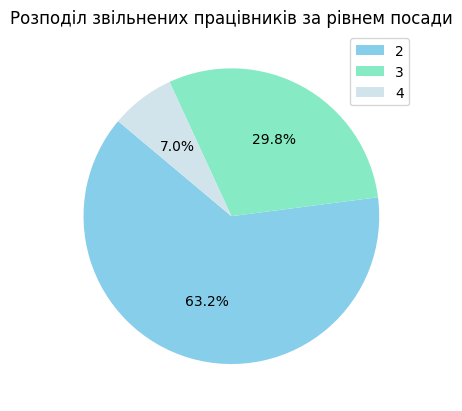

In [121]:
plt.pie(
    attr_se_joblevel["size"],
    labels=attr_se_joblevel["JobLevel"],
    colors=pie_colors,
    autopct="%1.1f%%",
    startangle=140,
    labeldistance=None,
)

plt.legend()

plt.title('Розподіл звільнених працівників за рівнем посади')

plt.show()

Найбільша частка звільнень припадає на спеціалістів 2 (63%) і 3 (30%) рівня; група спеціалістів 4 рівня найменш численна.

---

Оскільки команда Sales Executive найчисельніша у датасеті, а тренди відтоку відрізняються для спеціалістів різних рівнів даної посади, проаналізуємо спеціалістів 2 і 3 рівня окремо.


### Пошук тенденцій серед звільнених працівників 2-го рівня

In [122]:
# Створюємо датафрейм, який містить працівників 2 рівня
sales_ex_2 = sales_ex[sales_ex['JobLevel'] == 2].copy()

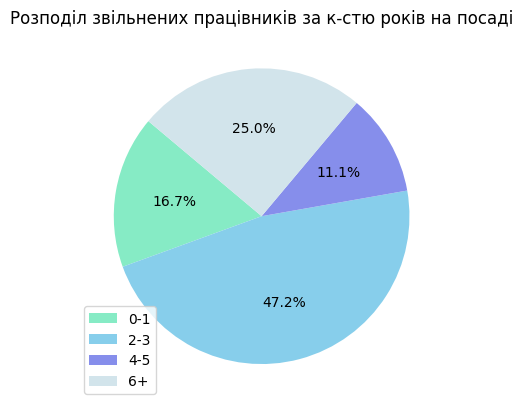

In [123]:
# Забираємо звільнених працівників
attr_se_2 = sales_ex_2[sales_ex_2['Attrition'] == True].copy()

# Групуємо працівників за терміном роботи і рахуємо кількість у кожній групі
attr_se2_tenure = attr_se_2.groupby('Tenure', as_index=False).size()

se2_pie_colors = ['#86EBC5', '#87CEEB', '#868EEB', '#D2E4EB']

plt.pie(
    attr_se2_tenure["size"],
    labels=attr_se2_tenure["Tenure"],
    colors=se2_pie_colors,
    autopct="%1.1f%%",
    startangle=140,
    labeldistance=None,
)

plt.legend()

plt.title('Розподіл звільнених працівників за к-стю років на посаді')

plt.show()

**Майже половина** звільнень відбувається в період з **2 до 3 років роботи**.

In [124]:
# Групуємо працівників за терміном роботи і шукаємо характерні ознаки
se_2_pivot = pd.pivot_table(
    sales_ex_2,
    values=[
        "AvgSatisfaction",
        "PerformanceRating",
        "YearsSinceLastPromotion",
        "OverTime",
    ],
    index="Tenure",
    columns="Статус працівника",
    aggfunc={
        "AvgSatisfaction": "mean",
        "PerformanceRating": "mean",
        "YearsSinceLastPromotion": "mean",
        "OverTime": "mean",
    },
    fill_value=0,
).round(1)

se_2_pivot['OverTime'] = (se_2_pivot['OverTime'] * 100).astype(str) + '%'

se_2_pivot

AvgSatisfaction          OverTime        PerformanceRating  \
Статус працівника      Звільнився Працює Звільнився Працює        Звільнився   
Tenure                                                                         
0-1                           2.6    2.8      50.0%  30.0%               3.0   
2-3                           2.3    2.7      50.0%  20.0%               3.0   
4-5                           2.7    2.8     100.0%  40.0%               3.0   
6+                            2.8    2.8      70.0%  20.0%               3.2   

                         YearsSinceLastPromotion         
Статус працівника Працює              Звільнився Працює  
Tenure                                                   
0-1                  3.0                     0.5    0.6  
2-3                  3.1                     1.1    0.9  
4-5                  3.2                     0.5    1.1  
6+                   3.2                     6.3    3.2

Маркером працівника у зоні ризику видається **низький рівень задоволеності** (менше 2.5) і **понаднормова праця** (серед звільнених працівників половина і більше працювали овертайм, в той час як дійсні працівники менш схильні до цього).

Також увагу привертає колонка YearsSinceLastPromotion для тих, хто працює на посаді **6+ років**. Довгострокові працівники схильні залишити компанію **через 6 років з останнього підвищення**.

### Пошук тенденцій серед звільнених працівників 3-го рівня

In [125]:
# Створюємо датафрейм, який містить працівників 3 рівня
sales_ex_3 = sales_ex[sales_ex['JobLevel'] == 3].copy()

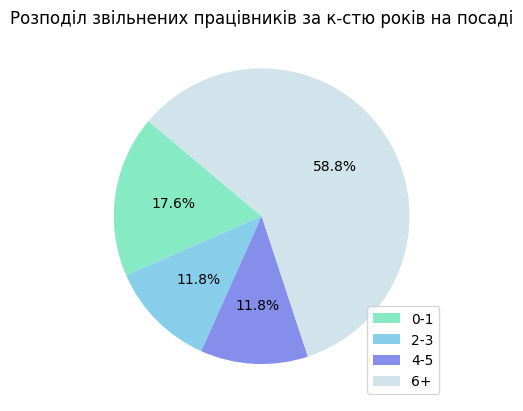

In [126]:
# Забираємо звільнених працівників
attr_se_3 = sales_ex_3[sales_ex_3['Attrition'] == True].copy()

# Групуємо працівників за терміном роботи і рахуємо кількість у кожній групі
attr_se3_tenure = attr_se_3.groupby('Tenure', as_index=False).size()

se3_pie_colors = ['#86EBC5', '#87CEEB', '#868EEB', '#D2E4EB']

plt.pie(
    attr_se3_tenure["size"],
    labels=attr_se3_tenure["Tenure"],
    colors=se3_pie_colors,
    autopct="%1.1f%%",
    startangle=140,
    labeldistance=None,
)

plt.legend()

plt.title('Розподіл звільнених працівників за к-стю років на посаді')

plt.show()

Більшість звільнень серед спеціалістів 3 рівня відбувається **після 6 років роботи**.

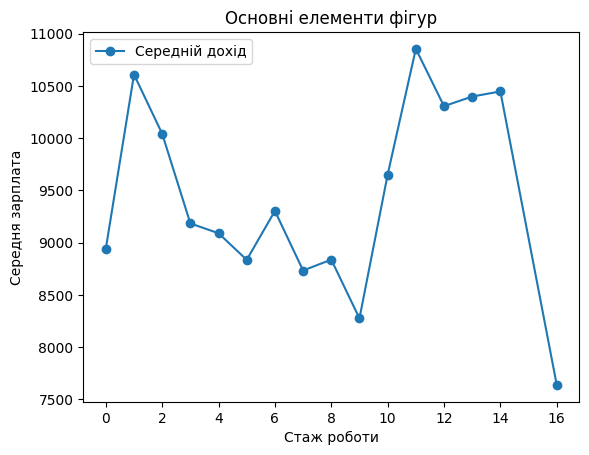

In [127]:
# Перевіряємо, якою є динаміка зарплат в залежності від стажу

# Групуємо працівників за стажем і рахуємо середнє значення зарплати
se3_gr_tenure = sales_ex_3.groupby('YearsInCurrentRole')['MonthlyIncome'].mean().reset_index()

# Візуалізуємо тренд
plt.plot(se3_gr_tenure['YearsInCurrentRole'], se3_gr_tenure['MonthlyIncome'], label = 'Середній дохід', marker='o')

plt.xlabel('Стаж роботи')
plt.ylabel('Середня зарплата')

plt.title('Основні елементи фігур')

plt.legend()
plt.show()

Лінійний графік показує, що на позиції існує **зарплатне плато — спеціалісти не отримують вищу винагороду із ростом стажу**, що може спонукати до відтоку.

In [128]:
# Групуємо працівників за терміном роботи і шукаємо характерні ознаки
se_3_pivot = pd.pivot_table(
    sales_ex_3,
    values=[
        "AvgSatisfaction",
        "PerformanceRating",
        "YearsSinceLastPromotion",
        "OverTime"
    ],
    index="Tenure",
    columns="Статус працівника",
    aggfunc={
        "AvgSatisfaction": "mean",
        "PerformanceRating": "mean",
        "YearsSinceLastPromotion": "mean",
        "OverTime": "mean"
    },
    fill_value=0,
).round(1)

se_3_pivot['OverTime'] = (se_3_pivot['OverTime'] * 100).astype(str) + '%'

se_3_pivot

AvgSatisfaction          OverTime        PerformanceRating  \
Статус працівника      Звільнився Працює Звільнився Працює        Звільнився   
Tenure                                                                         
0-1                           1.9    2.8      30.0%  30.0%               3.3   
2-3                           2.0    2.9     100.0%  40.0%               3.0   
4-5                           3.0    2.7      50.0%  20.0%               3.5   
6+                            2.7    2.8      30.0%  20.0%               3.2   

                         YearsSinceLastPromotion         
Статус працівника Працює              Звільнився Працює  
Tenure                                                   
0-1                  3.0                     3.7    0.1  
2-3                  3.0                     2.0    2.2  
4-5                  3.0                     1.0    5.2  
6+                   3.1                     4.7    4.6

Працівники стажу 6+ років **не відрізняються** низьким рівнем задоволеності, високою часткою понаднормової праці або зниженням продуктивності.

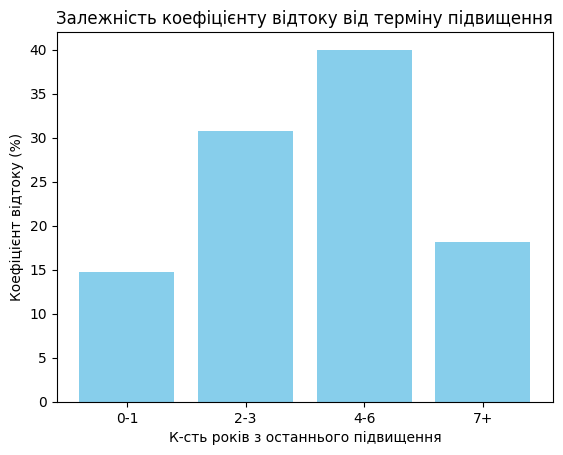

In [129]:
# Перевіримо вплив терміну підвищення
# Поділимо працівників на групи в залежності від к-сті років з останнього підвищення
def prom_gap(promyears):
    if promyears <= 1:
        return '0-1'
    elif promyears <= 3:
        return '2-3'
    elif promyears <= 6:
        return '4-6'
    else:
        return '7+'

sales_ex_3["PromotionGap"] = sales_ex_3['YearsSinceLastPromotion'].apply(prom_gap)

# Порахуємо коефіцієнт відтоку у кожній групі
se3_attr_prom = (
    sales_ex_3.groupby("PromotionGap", observed=False)["Attrition"].mean() * 100
)

plt.bar(se3_attr_prom.index, se3_attr_prom.values, color="#87CEEB")

plt.xlabel('К-сть років з останнього підвищення')
plt.ylabel('Коефіцієнт відтоку (%)')

plt.title('Залежність коефіцієнту відтоку від терміну підвищення')

plt.show()

Працівники, які **довше залишаються без підвищення, мають більшу схильність до відтоку**.

---


**Висновки**:

1. Посада Sales Executive характеризується вищим середнім віком і довшим стажем ніж посада Sales Representative. Найбільша частка звільнень припадає на спеціалістів 2 рівня, які покидають компанію після 2 років роботи. Для них маркерами є рівень задоволеності та наявність овертаймів: якщо такий працівник працює понаднормово та повідомляє про низький рівень задоволеності працею, є висока вірогідність, що він залишить компанію після 2 років роботи.

2. Спеціалісти 2-го рівня зі стажем 6+ років схильні до відтоку після 6 років роботи без підвищення.

3. Спеціалісти 3-го рівня схильні покидати компанію після 6 років на посаді через кар'єрний застій: рівень зарплати не зростає і працівники довго залишаються без підвищення.

## Laboratory Technician — відтік у перший рік роботи

In [130]:
# Створюємо датафрейм, який містить інформацію про робітників позиції Laboratory Technician
lab_tech = employees[employees['JobRole'] == 'Laboratory Technician'].copy()
lab_tech['Статус працівника'] = lab_tech['Attrition'].apply(lambda x: "Звільнився" if x else "Працює")
lab_tech['Tenure'] = lab_tech['YearsInCurrentRole'].apply(tenure)

### Аналіз віку і доходу працівників різних статусів

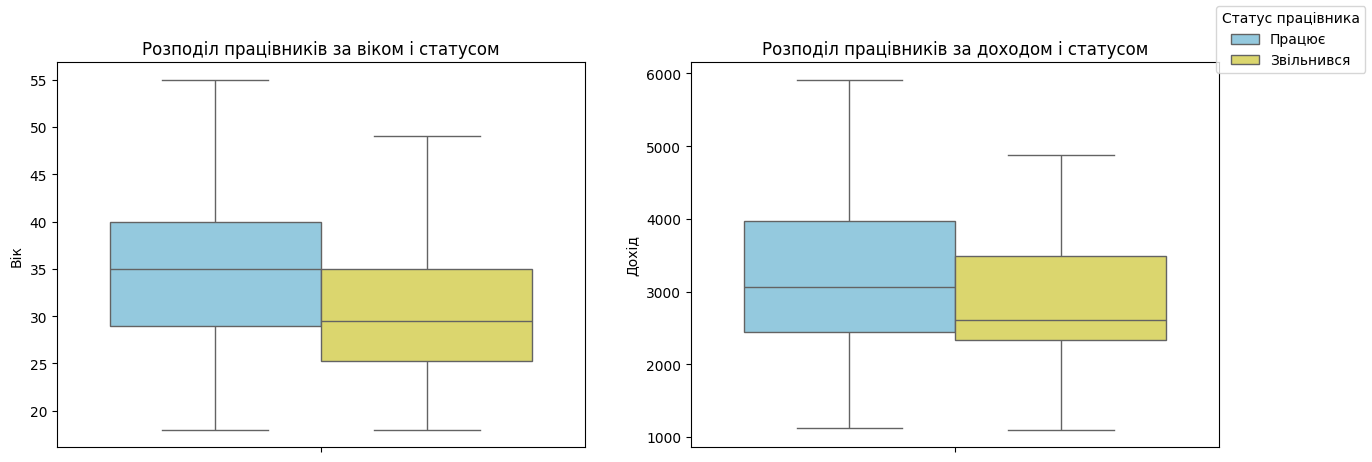

In [131]:
fig6, ax6 = plt.subplots(1, 2, figsize=(15, 5))
axes = ax6.flatten()

custom_colors = ["#87CEEB", "#EDE65C"]

sns.boxplot(ax=ax6[0], data=lab_tech, y="Age", hue="Статус працівника", palette=custom_colors, showfliers=False)
ax6[0].set_title('Розподіл працівників за віком і статусом')
ax6[0].set_ylabel('Вік')
ax6[0].get_legend().remove()

sns.boxplot(ax=ax6[1], data=lab_tech, y="MonthlyIncome", hue="Статус працівника", palette=custom_colors, showfliers=False)
ax6[1].set_title('Розподіл працівників за доходом і статусом')
ax6[1].set_ylabel('Дохід')
ax6[1].get_legend().remove()

handles, labels = ax6[0].get_legend_handles_labels()
fig6.legend(handles, labels, title="Статус працівника", loc="upper right")

plt.show()

**75% звільнених працівників молодші 35 років**, тоді як дійсні працівники зазвичай старші за них на 5 років.

Є **невелика різниця у зарплаті** — медіанне значення для звільнених працівників **2600** одиниць валюти, тоді як для дійсних працівників медіана становить 3000.

### Аналіз відтоку за віком працівників

In [132]:
# Зрупуємо дані за віковою групою і порахуємо коефіцієнт відтоку
lt_attr_age = round(
    lab_tech.groupby("AgeGroup")["Attrition"].mean() * 100, 1
).reset_index()

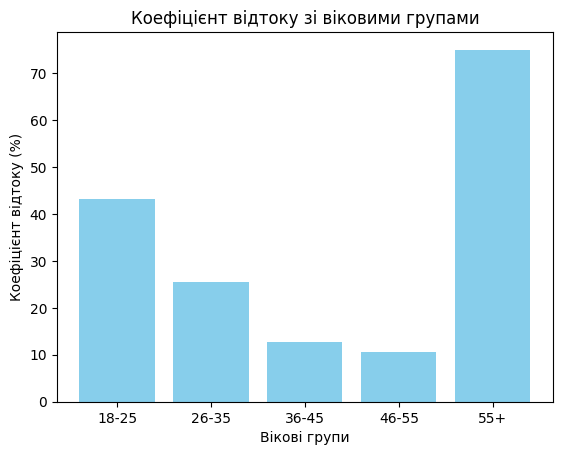

In [133]:
plt.bar(lt_attr_age['AgeGroup'], lt_attr_age['Attrition'], color="#87CEEB")

plt.xlabel('Вікові групи')
plt.ylabel('Коефіцієнт відтоку (%)')

plt.title('Коефіцієнт відтоку зі віковими групами')

plt.show()

Незвичайно високий коефіцієнт відтоку спостерігається для вікової групи **18-25 років (>40%)** та **26-35 років (25%)**. Після 35 років коефіцієнт суттєво падає.

Високий коефіцієнт для групи 55+ років пояснюється низькою чисельністю групи.

### Аналіз відтоку за віком і статтю працівників

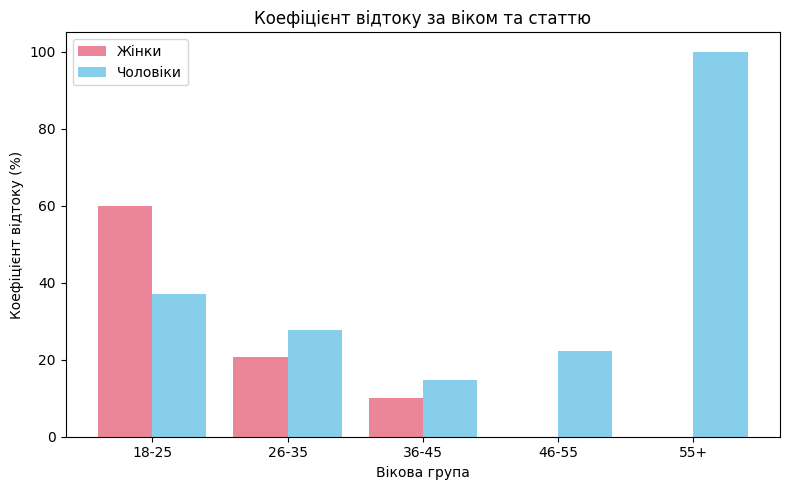

In [134]:
# Групуємо працівників за віковою групою та статтю; рахуємо коефіцієнт відтоку в кожній групі
lt_age_gender = round(
    lab_tech.groupby(["AgeGroup", "Gender"])["Attrition"].mean() * 100,
    1,
).unstack()

lt_age_gender_gr = lt_age_gender.index.copy()
x7 = np.arange(len(lt_age_gender_gr))
y_fem7 = lt_age_gender['Female'].copy()
y_male7 = lt_age_gender['Male'].copy()
width7 = 0.4

fig7, ax7 = plt.subplots(figsize=(8, 5))

ax7.bar(x7 - width7/2, y_fem7, width7, label='Жінки', color='#EB8699')
ax7.bar(x7 + width7/2, y_male7, width7, label='Чоловіки', color='#87CEEB')

ax7.set_ylabel('Коефіцієнт відтоку (%)')
ax7.set_xlabel('Вікова група')
ax7.set_title('Коефіцієнт відтоку за віком та статтю')
ax7.set_xticks(x7)
ax7.set_xticklabels(lt_age_gender_gr)
ax7.legend()

plt.tight_layout()
plt.show()

Вікова група **18-25** років характеризується більшим відтоком **жінок**, тоді як розподіл відтоку для групи 26-35 років вирівнюється.

### Розподіл звільнених працівників за терміном перебування на посаді

In [135]:
# Забираємо звільнених працівників
attr_lt = lab_tech[lab_tech['Attrition'] == True].copy()

# Групуємо працівників за терміном роботи і рахуємо кількість у кожній групі
attr_lt_tenure = attr_lt.groupby('Tenure', as_index=False).size()

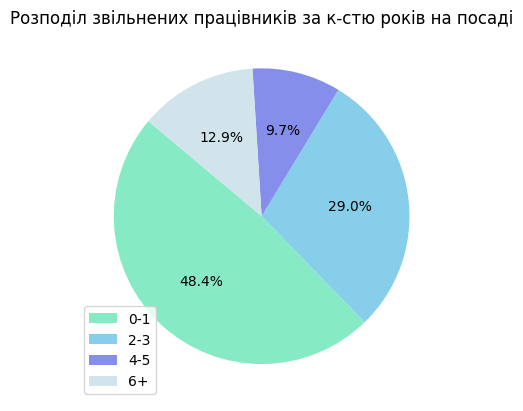

In [136]:
lt_pie_colors = ['#86EBC5', '#87CEEB', '#868EEB', '#D2E4EB']

plt.pie(
    attr_lt_tenure["size"],
    labels=attr_lt_tenure["Tenure"],
    colors=lt_pie_colors,
    autopct="%1.1f%%",
    startangle=140,
    labeldistance=None,
)

plt.legend()

plt.title('Розподіл звільнених працівників за к-стю років на посаді')

plt.show()

Половина звільнених працівників залишила компанію **у перший рік роботи**.

### Аналіз вливу двох факторів: вік + схильність до понаднормової праці

In [137]:
# Групуємо працівників за віковою групою та наявністю овертаймів; рахуємо коефіцієнт відтоку в кожній групі
lt_age_ot = round(
    lab_tech.groupby(["AgeGroup", "OverTime"])["Attrition"].mean() * 100,
    1,
).unstack()

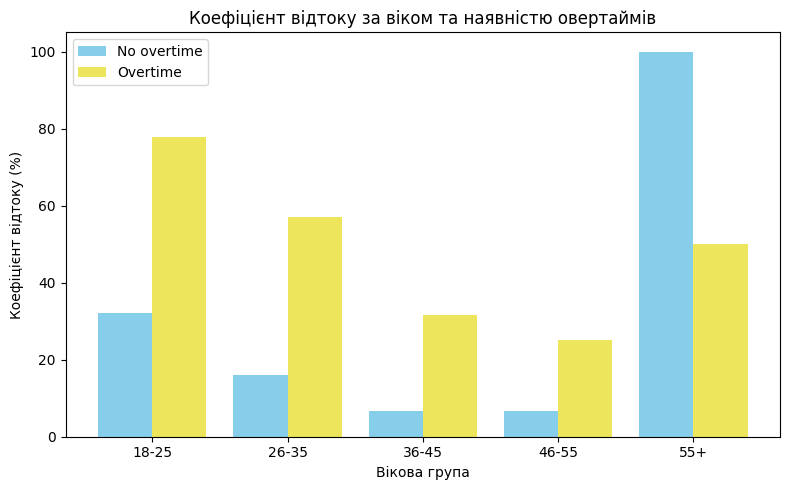

In [138]:
lt_age_groups = lt_age_ot.index.copy()
x8 = np.arange(len(lt_age_groups))
y_false8 = lt_age_ot[False].copy()
y_true8 = lt_age_ot[True].copy()
width8 = 0.4

fig8, ax8 = plt.subplots(figsize=(8, 5))

ax8.bar(x8 - width8/2, y_false8, width8, label='No overtime', color='#87CEEB')
ax8.bar(x8 + width8/2, y_true8, width8, label='Overtime', color='#EDE65C')

ax8.set_ylabel('Коефіцієнт відтоку (%)')
ax8.set_xlabel('Вікова група')
ax8.set_title('Коефіцієнт відтоку за віком та наявністю овертаймів')
ax8.set_xticks(x7)
ax8.set_xticklabels(lt_age_groups)
ax8.legend()

plt.tight_layout()
plt.show()

Серед усіх вікових груп найбільше понаднормова робота впливає на працівників **18-35 років**. Старші працівники менш схильні покинути компанію під вливом понаднормової праці.

### Неочікуваний фактор — опціони

In [139]:
# Розрахуємо, як рівень опціонів впливає на коефіцієнт відтоку серед працівників різних термінів праці
lt_pivot = pd.pivot_table(
    lab_tech,
    values=[
        "Attrition"
    ],
    index="Tenure",
    columns="StockOptionLevel",
    aggfunc={
        "Attrition": "mean"
    },
)

lt_pivot.style.format("{:.1%}", na_rep="")

Компанії можуть надавати найкращим працівникам опціони. Опціони дають право купити акції компанії за зниженою ціною, що надає вигоду при продажі цих акцій. Зазвичай, увесь обсяг опціонів не надається одразу, а розділений на рівні: напр., перші 25% опціонів надаються у перший рік, 50% — ще через рік роботи, і т.д. Така практика дозволяє утримати працівника на довший період, адже працівник захоче використати більшу частку опціонів, щоб отримати більше винагороди.

Таку саму систему ми спостерігаємо у поточному датасеті: працівники можуть володіти опціонами компанії на рівні від 0 до 3, де 0-й рівень означає відсутніть опціонів, а 3-й рівень — повний обсяг опціонів. У зведеній таблиці вище ми можемо спостерігати, **що коефіцієнт відтоку у кожній групі знижується зі зростанням рівня опціонів**. Це вказує на те, що наявність опціонів може заохочувати працівників залишитися у компанії довше.

---


**Висновки**:

Посада Laboratory Technician характеризується високим рівнем відтоку у перший рік роботи. Серед працівників найбільше схильні до відтоку люди до 35 років, які отримують менше 3000 одиниць валюти. Серед наймолодшої вікової групи найбільш схильні до відтоку жінки. Маркером працівника у зоні ризику слугує наявність понаднормової праці. Скоріше за все, команда недоукомплектована або має проблеми з розподілом робочого навантаження, через що працівники скоро починають шукати інші можливості з вищою зарплатою та нижчим навантаженням. Контроль навантаження і надання працівникам опціонів може бути способом заохотити їх до довшої співпраці.

## Human Resources — пошук нових можливостей у розквіті кар'єри

In [140]:
# Створюємо датафрейм, який містить інформацію про робітників позиції Human Resources
hr = employees[employees['JobRole'] == 'Human Resources'].copy()
hr['Статус працівника'] = hr['Attrition'].apply(lambda x: "Звільнився" if x else "Працює")
hr['Tenure'] = hr['YearsInCurrentRole'].apply(tenure)

### Аналіз віку і доходу працівників різних статусів

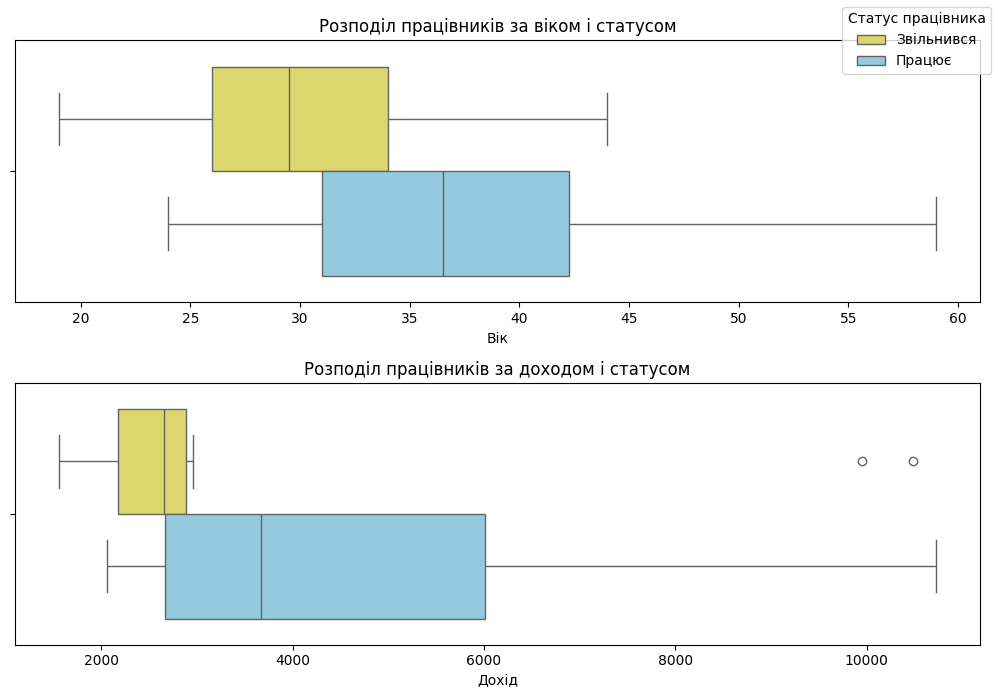

In [141]:
fig9, ax9 = plt.subplots(2, 1, figsize=(10, 7))
axes = ax9.flatten()

custom_colors = ["#EDE65C", "#87CEEB"]

sns.boxplot(ax=ax9[0], data=hr, x="Age", hue="Статус працівника", palette=custom_colors)
ax9[0].set_title('Розподіл працівників за віком і статусом')
ax9[0].set_xlabel('Вік')
ax9[0].get_legend().remove()

sns.boxplot(ax=ax9[1], data=hr, x="MonthlyIncome", hue="Статус працівника", palette=custom_colors)
ax9[1].set_title('Розподіл працівників за доходом і статусом')
ax9[1].set_xlabel('Дохід')
ax9[1].get_legend().remove()

handles, labels = ax9[0].get_legend_handles_labels()
fig9.legend(handles, labels, title="Статус працівника", loc="upper right")
plt.tight_layout()
plt.show()

Human Resources (HR) відділ включає лише одну позицію (за виключенням Manager) — HR, і вона найменш чисельна у датасеті (52 працівника).

Основна частина звільнених працівників має вік **25-35 років із медіаною 30 років**. Медіанний вік дійсних працівників набагато вищий — 37 років, і основна частина з них має вік 31-43 роки. Максимальний вік серед дійсних працівників 59 років (серед звільнених — 44).

Значна різниця існує між зарплатами дійсних і звільнених працівників. Якщо не враховувати два високі викиди, **максимальний рівень зарплати для звільнених працівників 3,000** валютних одиниць. В той самий час діапазон зарплат дійсних працівників охоплює 2,000-11,000.

### Розподіл звільнених працівників за терміном перебування на посаді

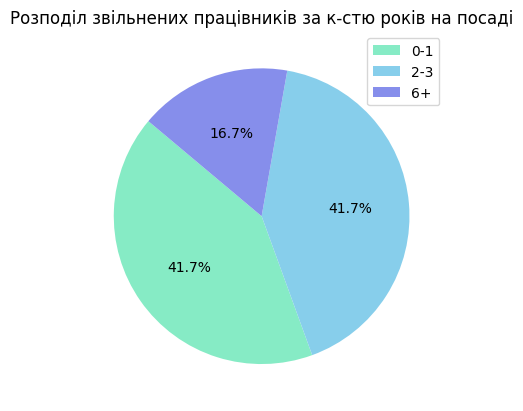

In [142]:
# Забираємо звільнених працівників
attr_hr = hr[hr['Attrition'] == True].copy()

# Групуємо працівників за терміном роботи і рахуємо кількість у кожній групі
attr_hr_tenure = attr_hr.groupby('Tenure', as_index=False).size()

hr_pie_colors = ['#86EBC5', '#87CEEB', '#868EEB', '#D2E4EB']

plt.pie(
    attr_hr_tenure["size"],
    labels=attr_hr_tenure["Tenure"],
    colors=se3_pie_colors,
    autopct="%1.1f%%",
    startangle=140,
    labeldistance=None,
)

plt.legend()

plt.title('Розподіл звільнених працівників за к-стю років на посаді')

plt.show()

Більшість звільнених працівників залишило компанію **у перші 3 роки роботи**.

### Пошук характерних ознак серед звільнених працівників

In [143]:
# Групуємо працівників за к-стю років на посаді та статусом і рахуємо середні значення по різним колонкам
hr_pivot = pd.pivot_table(
    hr,
    values=[
        "AvgSatisfaction",
        "TotalWorkingYears",
        "YearsSinceLastPromotion",
        "OverTime"
    ],
    index="Tenure",
    columns="Статус працівника",
    aggfunc={
        "AvgSatisfaction": "mean",
        "TotalWorkingYears": "mean",
        "YearsSinceLastPromotion": "mean",
        "OverTime": "mean"
    },
    fill_value=0,
).round(1)

hr_pivot['OverTime'] = (hr_pivot['OverTime'] * 100).astype(str) + '%'

hr_pivot

AvgSatisfaction          OverTime        TotalWorkingYears  \
Статус працівника      Звільнився Працює Звільнився Працює        Звільнився   
Tenure                                                                         
0-1                           2.8    3.0      20.0%  10.0%               2.2   
2-3                           2.6    2.7      60.0%  30.0%               6.0   
4-5                           0.0    2.7       0.0%   0.0%               0.0   
6+                            2.4    2.8      50.0%  20.0%              16.0   

                         YearsSinceLastPromotion         
Статус працівника Працює              Звільнився Працює  
Tenure                                                   
0-1                  8.6                     0.2    0.9  
2-3                  7.8                     1.0    0.9  
4-5                  7.5                     0.0    0.5  
6+                  11.4                     2.0    3.1

**У перший рік найчастіше звільняються спеціалісти-початківці, які мають менше 3 років робочого досвіду**. Загальний трудовий стаж дійсних працівників суттєво вищий.

Для спеціалістів, **які йдуть через 2-3 роки роботи, овертайм слугує маркером зони ризику**.

Звільнені працівники, які перебували на посаді **від 6 років**, повідомляли про **нижчий рівень задоволеності (2.4)**. Також є вірогідність, що довший термін підвищення серед них може спонукати до звільнення.

---


**Висновки**:

Посада HR характеризується високим рівнем відтоку у перші 3 роки роботи. Основну частку відтоку складають спеціалісти молодого віку до 35 років, які отримують менше 3000 одиниць валюти. Цікаво, що працівники з меншим трудовим стажем схильні покинути компанію у перший рік. Працівники, які залишаються довше, є більш досвідченими, і вони схильні до відтоку за наявності понаднормової праці.

Оскільки працівники часто звільняються після кількох років досвіду, можна припустити, що вони ідуть заради пошуку кар'єрного зростання в інших компаніях.

Для довготривалих працівників (6+ років на посаді) варто слідкувати за їхнім рівнем задоволеності (оцінка менше 2.5 повідомляє про ризик звільнення) та заохочувати їх підвищенням.

# Визначення працівників у зоні ризику

Пишемо функцію, яка **визначить дійсних працівників у зоні ризику** та заповнить 3 нові колонки в основному датафреймі: "**AttrRisk**", "**AttrReason**", "**Recommendations**". Перша буде містити True/False значення, де True означає, що працівник знаходиться у зоні ризику. Друга колонка міститиме основну характеристику працівника, яка пояснюватиме, чому він потрапив у зону ризику. Третя колонка міститиме ширше пояснення та рекомендації щодо утримання працівника.

Значення у колонках будуть залежати від сегменту, в який потрапив працівник. Наприклад, якщо один з працівників належить до ролі Sales Representative, працює менше 4 років на посаді, молодший за 31 рік та заробляє менше 2500 одиниць, а також працює понаднормово, його значеннями будуть:

*AttrRisk (boolean) = True*

*AttrReason (string) = "Стаж на посаді: {YearsInCurrentRole}; Вік: {Age}; Дохід: {MonthlyIncome}; Працює понаднормово"*

*Recommendations (string) = "Молоді працівники 2-3 років стажу на посаді Sales Representative схильні до відтоку за наявності понаднормової праці. Варто перевірити робоче навантаження та можливість компенсації."*

In [150]:
# Створюємо функцію

def assign_attrition_risk(row):

    # Default values
    attr_risk = False
    attr_reason = ""
    recommendations = ""

    # --- Case 1 ---
    if (
        row["JobRole"] == "Sales Representative"
        and row["Attrition"] == False
        and row["YearsInCurrentRole"] <= 3
        and row["Age"] <= 30
        and row["MonthlyIncome"] <= 2500
        and row["OverTime"] == True
    ):
        attr_risk = True
        attr_reason = f"Стаж на посаді: {row['YearsInCurrentRole']}; Вік: {row['Age']}; Дохід: {row['MonthlyIncome']}; Працює понаднормово"
        recommendations = "Молоді працівники 2-3 років стажу на посаді Sales Representative схильні до відтоку за наявності понаднормової праці. Варто перевірити робоче навантаження та можливість компенсації."

    # --- Case 2 ---
    elif (
        row["JobRole"] == "Sales Executive"
        and row["Attrition"] == False
        and row["JobLevel"] == 2
        and 2 <= row["YearsInCurrentRole"] <= 3
        and (row["AvgSatisfaction"] < 2.5 or row["OverTime"] == True)
    ):
        attr_risk = True
        attr_reason = f"Рівень посади: {row['JobLevel']}; Стаж на посаді: {row['YearsInCurrentRole']}; Задоволеність: {row['AvgSatisfaction']}; Наявність понаднормової праці: {row['OverTime']}"
        recommendations = "Спеціалісти Sales Executive 2 рівня часто покидають компанію після 2 років роботи. Варто дізнатися, чи задоволений працівник, та перевірити робоче навантаження."

    # --- Case 3 ---
    elif (
        row["JobRole"] == "Sales Executive"
        and row["Attrition"] == False
        and row["JobLevel"] == 2
        and row["YearsInCurrentRole"] >= 6
        and row["YearsSinceLastPromotion"] >= 6
    ):
        attr_risk = True
        attr_reason = f"Рівень посади: {row['JobLevel']}; Стаж на посаді: {row['YearsInCurrentRole']}; К-сть років з останнього підвищення: {row['YearsSinceLastPromotion']}"
        recommendations = "Спеціалісти Sales Executive 2-го рівня зі стажем 6+ років схильні до відтоку після 6 років роботи без підвищення. Варто дізнатися про перспективи для даного працівника."

    # --- Case 4 ---
    elif (
        row["JobRole"] == "Sales Executive"
        and row["Attrition"] == False
        and row["JobLevel"] == 3
        and row["YearsInCurrentRole"] >= 6
        and row["YearsSinceLastPromotion"] >= 2
    ):
        attr_risk = True
        attr_reason = f"Рівень посади: {row['JobLevel']}; Стаж на посаді: {row['YearsInCurrentRole']}; К-сть років з останнього підвищення: {row['YearsSinceLastPromotion']}"
        recommendations = "Спеціалісти Sales Executive 3-го рівня схильні покидати компанію після 6 років на посаді через кар'єрний застій. Варто перевірити можливість кар'єрного зростання для даного працівника, а також переглянути можливість заохочення опціонами/підвищенням."

    # --- Case 5 ---
    elif (
        row["JobRole"] == "Laboratory Technician"
        and row["Attrition"] == False
        and row["YearsInCurrentRole"] <= 1
        and row["Age"] <= 35
        and row["MonthlyIncome"] <= 3000
        and row["OverTime"] == True
    ):
        attr_risk = True
        attr_reason = f"Стаж на посаді: {row['YearsInCurrentRole']}; Вік: {row['Age']}; Дохід: {row['MonthlyIncome']}; Працює понаднормово"
        recommendations = "Посада Laboratory Technician характеризується високим рівнем відтоку у перший рік роботи. Варто перевірити робоче навантаження та конпенсацію."

    # --- Case 6 ---
    elif (
        row["JobRole"] == "Human Resources"
        and row["Attrition"] == False
        and row["YearsInCurrentRole"] <= 1
        and row["Age"] <= 35
        and row["MonthlyIncome"] <= 3000
        and row["TotalWorkingYears"] < 3
    ):
        attr_risk = True
        attr_reason = f"Стаж на посаді: {row['YearsInCurrentRole']}; Вік: {row['Age']}; Дохід: {row['MonthlyIncome']}; Загальний робочий стаж: {row['TotalWorkingYears']}"
        recommendations = "Працівники Human Resources з меншим трудовим стажем схильні покинути компанію у перший рік. Варто перевірити задоволеність працівника, рівень продуктивності і дізнатися про його перспективи."

    # --- Case 7 ---
    elif (
        row["JobRole"] == "Human Resources"
        and row["Attrition"] == False
        and 2 <= row["YearsInCurrentRole"] <= 3
        and row["Age"] <= 35
        and row["MonthlyIncome"] <= 3000
        and row["OverTime"] == True
    ):
        attr_risk = True
        attr_reason = f"Стаж на посаді: {row['YearsInCurrentRole']}; Вік: {row['Age']}; Дохід: {row['MonthlyIncome']}; Працює понаднормово"
        recommendations = "Працівники 2-3 років стажу на посаді Human Resources схильні до відтоку за наявності понаднормової праці. Варто перевірити робоче навантаження та можливість компенсації."

    # --- Case 8 ---
    elif (
        row["JobRole"] == "Human Resources"
        and row["Attrition"] == False
        and row["YearsInCurrentRole"] >= 6
        and row["AvgSatisfaction"] < 2.5
    ):
        attr_risk = True
        attr_reason = f"Стаж на посаді: {row['YearsInCurrentRole']}; Рівень задоволеності: {row['AvgSatisfaction']}"
        recommendations = "Серед довготривалих працівників посади Human Resources середній рівень задоволеності менше 2.5 повідомляє про ризик звільнення. Варто дізнатися про причини незадоволеності даного працівника та перевірити можливість заохочення опціонами/підвищенням."

    return pd.Series([attr_risk, attr_reason, recommendations])

In [151]:
# Створюємо новий датафрейм final_view, який міститиме нові колонки
final_view = employees.copy()
final_view[["AttrRisk", "AttrReason", "Recommendations"]] = final_view.apply(
    assign_attrition_risk, axis=1
)

In [153]:
# Експортуємо датафрейм у CSV файл для подальшої обробки у Tableau
from google.colab import files

final_view.to_csv('Hr_Analytics_final.csv', index=False)
files.download('Hr_Analytics_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>